In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("PrePlacement.csv")

In [3]:
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


# Question 1
#Replace the NAN values with correct values and justfiy that why you have chosen for the same.


#question 2
#How many of them are not placed


In [4]:
not_placed=dataset[dataset["status"]=="Not Placed"]


In [5]:
not_placed

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
3,4,M,56.0,Central,52.0,Central,Science,52.00,Sci&Tech,No,66.00,Mkt&HR,59.43,Not Placed,NaN
5,6,M,55.0,Others,49.8,Others,Science,67.25,Sci&Tech,Yes,55.00,Mkt&Fin,51.58,Not Placed,NaN
6,7,F,46.0,Others,49.2,Others,Commerce,79.00,Comm&Mgmt,No,74.28,Mkt&Fin,53.29,Not Placed,NaN
9,10,M,58.0,Central,70.0,Central,Commerce,61.00,Comm&Mgmt,No,54.00,Mkt&Fin,52.21,Not Placed,NaN
12,13,F,47.0,Central,55.0,Others,Science,65.00,Comm&Mgmt,No,62.00,Mkt&HR,65.04,Not Placed,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,199,F,67.0,Central,70.0,Central,Commerce,65.00,Others,No,88.00,Mkt&HR,71.96,Not Placed,NaN
201,202,M,54.2,Central,63.0,Others,Science,58.00,Comm&Mgmt,No,79.00,Mkt&HR,58.44,Not Placed,NaN
206,207,M,41.0,Central,42.0,Central,Science,60.00,Comm&Mgmt,No,97.00,Mkt&Fin,53.39,Not Placed,NaN
208,209,F,43.0,Central,60.0,Others,Science,65.00,Comm&Mgmt,No,92.66,Mkt&HR,62.92,Not Placed,NaN


In [6]:
#67 rows are  not placed

#Question 3 


#Find out the reason for non placement data from the dataset
#It is essential to train the machine learning algorithm to distinguisg the characteristics of both placed and not placed data rather than having placement data.

#Question 4


In [7]:
#what kind of relation between salary and mba_p


In [8]:
dataset.corr()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
sl_no,1.000000,-0.078155,-0.085711,-0.088281,0.063636,0.022327,0.063764
ssc_p,-0.078155,1.000000,0.511472,0.538404,0.261993,0.388478,0.035330
hsc_p,-0.085711,0.511472,1.000000,0.434206,0.245113,0.354823,0.076819
degree_p,-0.088281,0.538404,0.434206,1.000000,0.224470,0.402364,-0.019272
etest_p,0.063636,0.261993,0.245113,0.224470,1.000000,0.218055,0.178307
mba_p,0.022327,0.388478,0.354823,0.402364,0.218055,1.000000,0.175013
salary,0.063764,0.035330,0.076819,-0.019272,0.178307,0.175013,1.000000


In [9]:
#The correlation between mba passmark salary is a positive correlation. it is directly propotional.it is incraesing with 0.17percent.

#Question5 


In [10]:
#which specialization is getting minimum salary

In [11]:
lowest_salary_row = dataset.loc[dataset['salary'].idxmin()]
print(lowest_salary_row['specialisation'])

Mkt&Fin


In [12]:
min_spec = dataset.groupby('specialisation')['salary'].mean().idxmin()
min_value = dataset.groupby('specialisation')['salary'].mean().min()

In [13]:
min_spec

'Mkt&HR'

In [14]:
min_value

270377.358490566

#question 6 


In [15]:
#how many of them are getting above 500000 salary

In [16]:
count = (dataset['salary'] > 500000).sum()


In [17]:
count

3

#Question 7


In [28]:
#Test the analysis of variance between  etest _p and mba_p at significance level 5% (make decision using hyothesis testing)
#The null hypothesis is rejected at the 5% significance level, as there is a statistically significant difference between the means of etest_p and mba_p. 
import scipy.stats as stats
stats.f_oneway(dataset["etest_p"],dataset["mba_p"])


F_onewayResult(statistic=75.35669909200762, pvalue=2.7511196898832345e-16)

#question 8

In [18]:
#Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary at significance level of 5%.
#(Makedecision using Hypothesis Testing)

from scipy.stats import ttest_ind
dataset=dataset.dropna()
group_sci_tech= dataset[dataset["degree_t"]=="Sci&Tech"]["salary"]
group_mkt_hr= dataset[dataset["specialisation"]=="Mkt&HR"]["salary"]
#print(degree_t)
ttest_ind(group_sci_tech, group_mkt_hr)


Ttest_indResult(statistic=2.734391160944239, pvalue=0.007496896218767113)

In [19]:
# At a 5% significance level, we can conclude that there is no significant difference between the salaries of 
#degree holders and specialists. Therefore, the two groups are statistically similar regarding salary

#question  9

In [20]:
#)Convert the normal distribution to standard normal distribution for salary column
# Calculate mean and standard deviation
mean_salary = dataset['salary'].mean()
std_salary = dataset['salary'].std()

# Apply the Z-score formula
dataset['Standardized_salary'] = (dataset['salary'] - mean_salary) / std_salary


C:\Users\SENTHIL\anaconda3\envs\aiml\lib\site-packages\ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys


In [21]:
dataset['Standardized_salary'] 

0     -0.199614
1     -0.948618
2     -0.413615
4      1.458895
7     -0.392215
         ...   
209   -0.777417
210    1.191393
211   -0.146114
212    0.067888
213   -0.905818
Name: Standardized_salary, Length: 148, dtype: float64

#question  10

In [29]:
#What is the probability Density Function of the salary range from 700000 to 900000
from scipy.stats import uniform

# Define salary bounds
lower_bound = 700000
upper_bound = 900000
range_width = upper_bound - lower_bound

# Calculate PDF value (1 / range)
# 'loc' is the start, 'scale' is the width (b-a)
pdf_value = uniform.pdf(800000, loc=lower_bound, scale=range_width)

print(f"The PDF value for the range {lower_bound}-{upper_bound} is: {pdf_value:.7f}")
# Output: The PDF value for the range 700000-900000 is: 0.0000050


The PDF value for the range 700000-900000 is: 0.0000050


#question 11

In [36]:
#Test the similarity between the degree_t(Sci&Tech)with respect to etest_p and mba_p at significance level of 5%.(Make decision using Hypothesis Testing)

from scipy.stats import ttest_ind
dataset=dataset.dropna()
# 2. Filter data for Science & Technology degree holders
scitech_df = dataset[dataset['degree_t'] == 'Sci&Tech']

# 3. Extract the two score columns
group_etest = scitech_df['etest_p']
group_mba = scitech_df['mba_p']

# 4. Perform Paired Sample T-test
t_stat, p_value = stats.ttest_rel(group_etest, group_mba)

# 5. Output Results
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
alpha = 0.05
if p_value < alpha:
    print("Decision: Reject the Null Hypothesis.")
    print("Conclusion: The scores are NOT similar (Significant difference).")
else:
    print("Decision: Fail to Reject the Null Hypothesis.")
    print("Conclusion: The scores ARE similar (No significant difference).")



T-statistic: 4.9155
P-value: 0.000015
Decision: Reject the Null Hypothesis.
Conclusion: The scores are NOT similar (Significant difference).


#questin 12

In [38]:
#Which parameter is highly correlated with salary?

# Calculate correlation matrix
# Assuming 'Salary' is your target variable
correlation_matrix = df.corr()

# Sort correlations with Salary
salary_corr = correlation_matrix['salary'].sort_values(ascending=False)
print(salary_corr)


salary      1.000000
etest_p     0.178307
mba_p       0.175013
hsc_p       0.076819
sl_no       0.063764
ssc_p       0.035330
degree_p   -0.019272
Name: salary, dtype: float64


#question  13

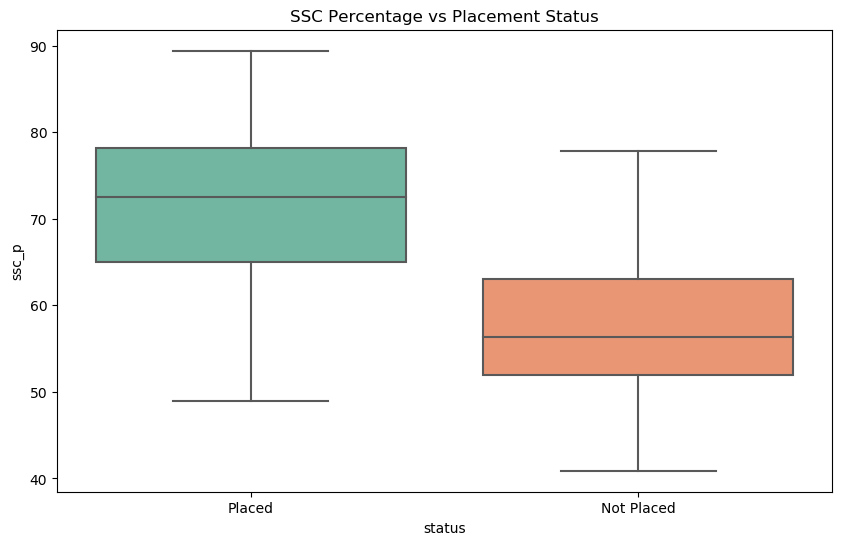

In [26]:
#plot any useful graph and explain it.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('PrePlacement.csv')

# Create Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='status', y='ssc_p', data=df, palette='Set2')

plt.title('SSC Percentage vs Placement Status')
plt.show()






In [27]:
#Median Difference: The  line inside the "Placed" box is significantly higher than the "Not Placed" box. 
#This shows us on average, placed students have much higher high school scores.
#Interquartile Range (IQR): The green box represents the middle 50% of students. 
# The "Placed" group's box is tighter and positioned higher, 
#suggesting a more consistent academic requirement for recruitment.
# Predictive Power: Because there is very little overlap between the two boxes, 
    #we can conclude that ssc_p is one of the strongest predictors of placement success in this dataset.

question 14

In [ ]:
# plot any useful graph and explain it.


In [42]:
dataset=pd.read_csv("PrePlacement.csv")

In [43]:
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


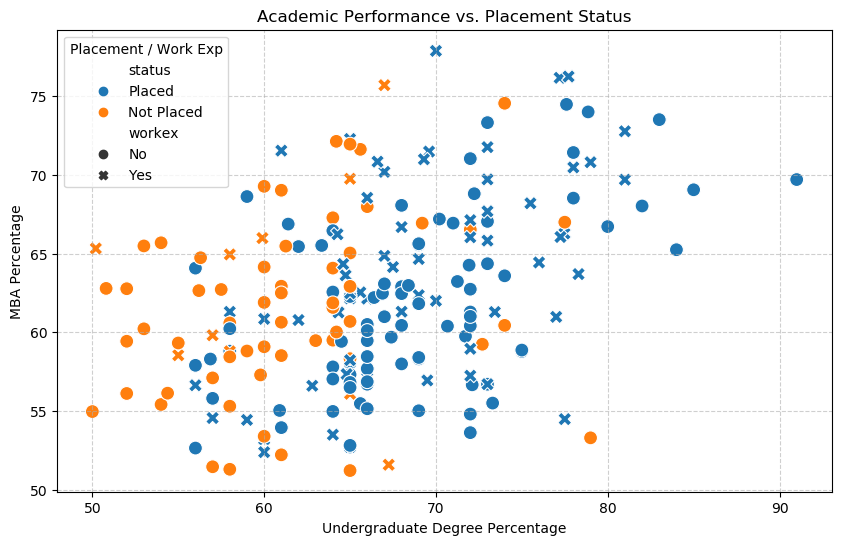

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# dataset = pd.read_csv('placement_data.csv')

# Scatter plot: Degree % vs MBA % colored by Placement Status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='degree_p', y='mba_p', hue='status', style='workex', s=100)

plt.title('Academic Performance vs. Placement Status')
plt.xlabel('Undergraduate Degree Percentage')
plt.ylabel('MBA Percentage')
plt.legend(title='Placement / Work Exp')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
